# **Part 1**

**Read Files**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import math
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("sentiment.csv")

# Convert numerical columns to numeric type (if not already)
numeric_columns = ['followers', 'previous_posts_count', 'post_likes', 'posts_retweets']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Calculate Engagement Rate
df = df[df['followers'] > 0]  # מניעת חילוק באפס
df.loc[:, 'engagement_rate'] = df['post_likes'] / df['followers']
df.to_csv('sentiment.csv', index=False)

In [ ]:
df['account_creation_date'] = pd.to_datetime(df['account_creation_date'], dayfirst=True)
# Calculate the number of months the user has been active
today = datetime.today()
df['months_active'] = ((today.year - df['account_creation_date'].dt.year) * 12) + (today.month - df['account_creation_date'].dt.month)
df.to_csv('sentiment.csv', index=False)

In [ ]:
df['birthday'] = pd.to_datetime(df['birthday'], dayfirst=True, errors='coerce')
df['age'] = (today - df['birthday']).dt.days // 365  # Calculate the user's age in years
df.to_csv('sentiment.csv', index=False)

**Pre-Procecing**

In [ ]:
# Remove rows where 'followers' is '?'
df = df[df['followers'] != '?']
# Remove rows where 'username' is '?'
df = df[df['username'] != '?']

#Converting columns to binary
df['embedded_content_url'] = df['embedded_content_url'].apply(lambda x: 1 if pd.notnull(x) else 0)
df['profile_picture'] = df['profile_picture'].apply(lambda x: 1 if pd.notnull(x) else 0)
df['email'] = df['email'].apply(lambda x: 1 if pd.notnull(x) else 0).astype(int)
df['username'] = df['username'].apply(lambda x: 1 if pd.notnull(x) else 0).astype(int)
df.to_csv('sentiment.csv', index=False)

In [ ]:
df['post_datetime'] = pd.to_datetime(df['post_datetime'], errors='coerce', dayfirst=True)
# Retrieving the name of the day from the date
df['day_posted'] = df['post_datetime'].dt.day_name()
# One-Hot Encoding
df = pd.get_dummies(df, columns=['day_posted'], prefix='day_posted')
df.to_csv('sentiment.csv', index=False)

In [ ]:
df['hour_posted'] = df['post_datetime'].dt.hour
# Division into categories by hours
df['time_of_day'] = pd.cut(
    df['hour_posted'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
    right=False
)

# One-Hot Encoding
df = pd.get_dummies(df, columns=['time_of_day'], prefix='time_of_day')
df.to_csv('sentiment.csv', index=False)


In [ ]:
# Make sure the dates are correct
df['post_datetime'] = pd.to_datetime(df['post_datetime'], dayfirst=True, errors='coerce')
df['Is_Weekend'] = df['post_datetime'].dt.weekday.isin([5, 6]).astype(int)
df.to_csv('sentiment.csv', index=False)

In [ ]:
df['Text_length'] = df['text'].apply(lambda x: len(x.split()) if pd.notnull(x) else 0)
df.to_csv('sentiment.csv', index=False)

In [ ]:
words_df = pd.read_excel('sentiment_words.xlsx')
positive_words = words_df['positive_words'].dropna().tolist()
negative_words = words_df['negative_words'].dropna().tolist()

df['Positive_word_count'] = df['text'].apply(
    lambda x: sum(1 for word in str(x).lower().split() if word in positive_words)
)

df['Negative_word_count'] = df['text'].apply(
    lambda x: sum(1 for word in str(x).lower().split() if word in negative_words)
)
df.to_csv('sentiment.csv', index=False)

In [ ]:
# Calculate the ratio between positive and negative words
df['Sentiment_Ratio'] = df['Positive_word_count'] / (df['Negative_word_count'] + 1)  # Adding 1 to prevent division by 0

# Calculate the number of hashtags in a message
df['Hashtags_Count'] = df['text'].apply(lambda x: x.count('#'))
df.to_csv('sentiment.csv', index=False)

In [ ]:
pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 7.3 MB/s eta 0:00:00


In [ ]:
import emoji

# Function that counts emojis in text
def count_emojis(text):
    return sum(1 for char in text if char in emoji.EMOJI_DATA)

# Adding a new column to the DataFrame
df['emoji_count'] = df['text'].astype(str).apply(count_emojis)
df.to_csv('sentiment.csv', index=False)

In [ ]:
df = df.drop(columns=['followers', 'posts_retweets', 'emoji_count'])
df.to_csv('sentiment.csv', index=False)

In [ ]:
type_mapping = {'post': 1, 'reply': 2, 'retweet': 3}
df['type'] = df['type'].map(type_mapping)
df.to_csv('sentiment.csv', index=False)

In [ ]:
checkmark_map = {
    'none': 0,   # Private, free account
    'blue': 1,   # Private, Premium Account
    'gold': 2,   # Official account of an organization
    'grey': 3    # חשבון רשמי של ממשלה
}

# המרה ל-label encoding
df['checkmark'] = df['checkmark'].map(checkmark_map)
df.to_csv('sentiment.csv', index=False)

In [ ]:
# Mapping of acronyms to hours from UTC
timezone_offset_map = {
    'GMT': 0,
    'UTC': 0,
    'EST': -5,
    'CST': -6,
    'MST': -7,
    'PST': -8,
    'EET': 2,
    'CET': 1,
    'MSK': 3,
    'AEST': 10,
    'ACST': 9.5,
    'AWST': 8
}

df['timezone_offset'] = df['timezone'].map(timezone_offset_map).fillna(0)
df.to_csv('sentiment.csv', index=False)


In [ ]:
# רשימת העמודות לעיבוד
columns_to_convert = [
    'day_posted_Sunday',
    'day_posted_Saturday',
    'day_posted_Friday',
    'day_posted_Monday',
    'day_posted_Tuesday',
    'day_posted_Wednesday',
    'day_posted_Thursday',
    'time_of_day_Night',
    'time_of_day_Morning',
    'time_of_day_Afternoon',
    'time_of_day_Evening'
]

# המרת ערכים בוליאניים ל-0/1
for col in columns_to_convert:
    df[col] = df[col].astype(int)
df.to_csv('sentiment.csv', index=False)

# **Part 2**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# סינון כל הדאטה משורות עם '?'
df_clean = df[df['sentiment'].isin(['positive', 'negative'])].copy()

# מיפוי ל-0/1
sentiment_map = {'negative': 0, 'positive': 1}
df_clean['sentiment'] = df_clean['sentiment'].map(sentiment_map)

In [ ]:
# הפרדת משתנים מסבירים ומשתנה מטרה
X = df_clean.drop(['sentiment', 'id', 'text', 'post_datetime', 'timezone', 'account_creation_date', 'birthday'], axis=1)
y = df_clean['sentiment']

In [ ]:
# Split data into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# הסרת NaN (במקרה שנשארו) מתוך y_train
mask = ~y_train.isna()
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

# פיצול נוסף ל-Train/Validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_clean, y_train_clean, test_size=0.2, stratify=y_train_clean, random_state=42
)

In [ ]:
# השלמת ערכים חסרים
imputer = SimpleImputer(strategy='mean')
X_tr_imputed = imputer.fit_transform(X_tr)
X_val_imputed = imputer.transform(X_val)
X_test_imputed = imputer.transform(X_test)

# נירמול (Standardization)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_imputed)
X_val_s = scaler.transform(X_val_imputed)
X_test_s = scaler.transform(X_test_imputed)

# **SVM**

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

In [ ]:
# 1. סינון שורות עם NaN (אם עדיין קיימות)
valid_idx = X_train.dropna().index
X_train_clean = X_train.loc[valid_idx]
y_train_clean = y_train.loc[valid_idx]

# 2. השלמת ערכים
imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_clean), columns=X_train_clean.columns)

# 3. נרמול
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train_imputed)

# עכשיו האימון:
model = SVC(kernel='linear', C=1.0)
model.fit(X_train_s, y_train_clean)

SVC(kernel='linear')

In [ ]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train_clean, model.predict(X_train_s))
val_acc = accuracy_score(y_test, model.predict(X_test_s))

In [ ]:
print("Train Accuracy:", train_acc)
print("Test Accuracy:", val_acc)

Train Accuracy: 0.801178105764776
Test Accuracy: 0.8027096774193548


In [ ]:
import pandas as pd
import numpy as np

feature_names = ['type', 'post_likes', 'embedded_content_url', 'username', 'checkmark',
                 'email', 'profile_picture', 'previous_posts_count', 'engagement_rate',
                 'months_active', 'age', 'day_posted_Friday', 'day_posted_Monday',
                 'day_posted_Saturday', 'day_posted_Sunday', 'day_posted_Thursday',
                 'day_posted_Tuesday', 'day_posted_Wednesday', 'hour_posted',
                 'time_of_day_Night', 'time_of_day_Morning', 'time_of_day_Afternoon',
                 'time_of_day_Evening', 'Is_Weekend', 'Text_length',
                 'Positive_word_count', 'Negative_word_count', 'Sentiment_Ratio',
                 'Hashtags_Count', 'timezone_offset']

# שליפת מקדמי הישר המפריד
w = model.coef_[0]

# חשיבות = ערך מוחלט של המשקל
importance = np.abs(w)

# טבלה מסודרת של הפיצ'רים והחשיבות שלהם
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': w,
    'Importance (|weight|)': importance
})

# מיון לפי חשיבות
importance_df = importance_df.sort_values(by='Importance (|weight|)', ascending=False)

# הדפסת הטבלה
print(importance_df.to_string(index=False))


              Feature    Weight  Importance (|weight|)
      engagement_rate 10.442776              10.442776
  Negative_word_count -5.861366               5.861366
 previous_posts_count  4.776923               4.776923
       Hashtags_Count  4.023080               4.023080
      Sentiment_Ratio  2.647768               2.647768
  Positive_word_count  2.021578               2.021578
        months_active -1.912816               1.912816
            checkmark  1.330692               1.330692
  time_of_day_Evening -0.322230               0.322230
          Text_length  0.313686               0.313686
  time_of_day_Morning  0.313555               0.313555
      profile_picture  0.236080               0.236080
           post_likes -0.162666               0.162666
time_of_day_Afternoon  0.129183               0.129183
    time_of_day_Night -0.120508               0.120508
          hour_posted  0.072040               0.072040
      timezone_offset -0.070428               0.070428
 embedded_

# **Decision Tree**

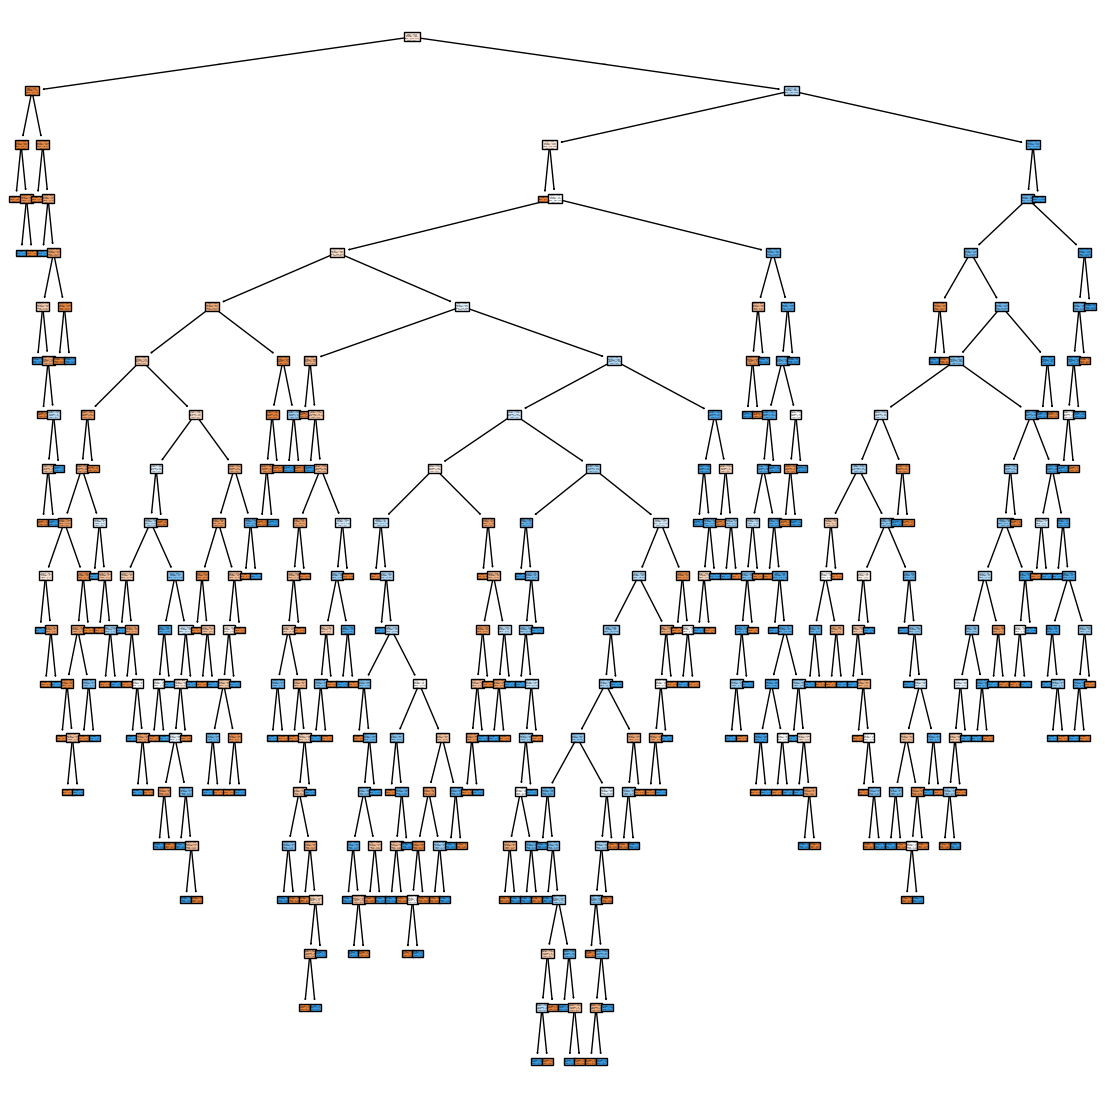

In [ ]:
# Build a full Decision Tree model using entropy
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)
plt.figure(figsize=(14, 14))
plot_tree(model, filled=True, class_names=True)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

# טווחי ההיפר-פרמטרים
param_grid = {
    'max_depth': np.arange(1, 16),  # עומק 1 עד 15
    'criterion': ['gini', 'entropy'],
    'max_features': np.arange(5, 21)
}

# הגדרת GridSearchCV עם דיוק (accuracy) כמדד
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,                       # קיפול צולב עם 5 חלקים
    refit=True,                 # בסיום יאמן מחדש את המודל הטוב ביותר על כל ה-Train
    verbose=1,                  # מדפיס התקדמות
    return_train_score=True     # מחזיר גם תוצאות אימון להשוואה
)

# הרצת הגריד על הנתונים
grid_search.fit(X_train, y_train)

# שמירת המודל האופטימלי
best_model = grid_search.best_estimator_

# הצגת ההיפר-פרמטרים האופטימליים
print("Best parameters:", grid_search.best_params_)
print("Best accuracy score (CV):", grid_search.best_score_)

# דיוק על סט האימון והבדיקה
train_preds = best_model.predict(X_train)
test_preds = best_model.predict(X_test)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print(f"Train Accuracy (DT): {train_acc}")
print(f"Test Accuracy (DT): {test_acc}")



Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Best parameters: {'criterion': 'entropy', 'max_depth': np.int64(11), 'max_features': np.int64(19)}
Best accuracy score (CV): 0.8773429533379474
Train Accuracy (DT): 0.9017646869051844
Test Accuracy (DT): 0.8783225806451613


In [ ]:
print(y_train.shape)
print(y_train[:5])


(30997,)
31768    1
26846    1
23974    0
38174    0
13024    1
Name: sentiment, dtype: int64


In [ ]:
from sklearn.metrics import roc_auc_score

# תחזיות הסתברותיות (שתי עמודות: [prob_negative, prob_positive])
train_probs = best_model.predict_proba(X_train)
test_probs = best_model.predict_proba(X_test)

# חישוב AUC לפי ההסתברות למחלקה החיובית בלבד (positive = 1)
train_auc = roc_auc_score(y_train, train_probs[:, 1])
test_auc = roc_auc_score(y_test, test_probs[:, 1])

# הדפסת התוצאות
print(f"Train AUC: {round(train_auc, 3)}")
print(f"Test AUC: {round(test_auc, 3)}")


Train AUC: 0.97
Test AUC: 0.938


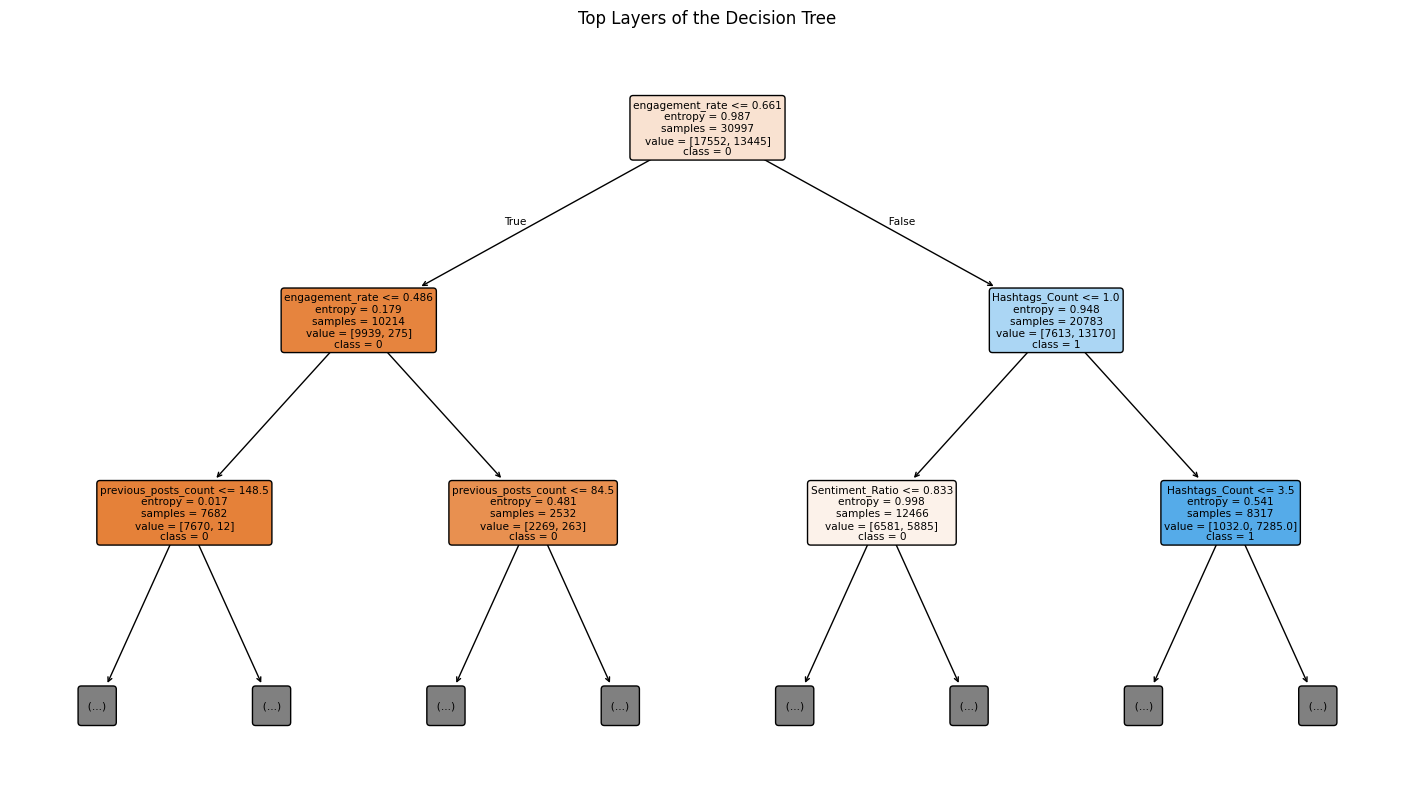

In [ ]:
plt.figure(figsize=(18, 10))
plot_tree(best_model,
          feature_names=X_train.columns,
          class_names=best_model.classes_.astype(str),
          filled=True,
          rounded=True,
          max_depth=2)
plt.title("Top Layers of the Decision Tree")
plt.show()

In [ ]:
importance = best_model.feature_importances_
feature_importance_dataframe = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)
print(feature_importance_dataframe)


                  Feature  Importance
8         engagement_rate    0.482033
28         Hashtags_Count    0.170986
1              post_likes    0.082961
7    previous_posts_count    0.076638
27        Sentiment_Ratio    0.043513
4               checkmark    0.038934
9           months_active    0.026757
26    Negative_word_count    0.019434
10                    age    0.014436
24            Text_length    0.010884
18            hour_posted    0.009483
29        timezone_offset    0.004773
20    time_of_day_Morning    0.004159
6         profile_picture    0.003756
25    Positive_word_count    0.003655
23             Is_Weekend    0.001491
16     day_posted_Tuesday    0.001263
21  time_of_day_Afternoon    0.000966
19      time_of_day_Night    0.000898
0                    type    0.000898
11      day_posted_Friday    0.000516
2    embedded_content_url    0.000433
15    day_posted_Thursday    0.000390
22    time_of_day_Evening    0.000270
17   day_posted_Wednesday    0.000228
13    day_po

# **MLP**

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

In [ ]:
print(X_train.isnull().sum())  # לכל עמודה


type                       0
post_likes               378
embedded_content_url       0
username                   0
checkmark                  0
email                      0
profile_picture            0
previous_posts_count       0
engagement_rate          378
months_active              0
age                        0
day_posted_Friday          0
day_posted_Monday          0
day_posted_Saturday        0
day_posted_Sunday          0
day_posted_Thursday        0
day_posted_Tuesday         0
day_posted_Wednesday       0
hour_posted              401
time_of_day_Night          0
time_of_day_Morning        0
time_of_day_Afternoon      0
time_of_day_Evening        0
Is_Weekend                 0
Text_length                0
Positive_word_count        0
Negative_word_count        0
Sentiment_Ratio            0
Hashtags_Count             0
timezone_offset            0
dtype: int64


In [ ]:
# סינון דוגמאות עם תווית חוקית
mask_train = y_train != '?'
X_train_f = X_train[mask_train]
y_train_f = y_train[mask_train]

mask_test = y_test != '?'
X_test_f = X_test[mask_test]
y_test_f = y_test[mask_test]

# קידוד תוויות
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_f)
y_test_enc = le.transform(y_test_f)

# השלמת ערכים חסרים
imputer = SimpleImputer(strategy='mean')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_f), columns=X_train.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test_f), columns=X_test.columns)

# נירמול
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_imp)
X_test_s = scaler.transform(X_test_imp)

# אימון MLP
model = MLPClassifier(random_state=1, hidden_layer_sizes=(100,), max_iter=1000, activation='logistic')
model.fit(X_train_s, y_train_enc)

# ניבוי והערכת דיוק
y_pred = model.predict(X_test_s)
print("Accuracy:", accuracy_score(y_test_enc, y_pred))

Accuracy: 0.8699354838709678


In [ ]:
param_grid = {
    'hidden_layer_sizes': [(100,), (100, 50)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.0001],
    'learning_rate': ['constant']
}

In [ ]:
scorer = make_scorer(f1_score, average='weighted', zero_division=0)

# קיפול צולב
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# הרצת GridSearchCV
grid_search = GridSearchCV(
    estimator=MLPClassifier(max_iter=400, random_state=42),
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    verbose=2,
    n_jobs=-1,
    error_score='raise',
    return_train_score=True

)

grid_search.fit(X_train_s, y_train_enc)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             error_score='raise',
             estimator=MLPClassifier(max_iter=400, random_state=42), n_jobs=-1,
             param_grid={'activation': ['relu'], 'alpha': [0.0001],
                         'hidden_layer_sizes': [(100,), (100, 50)],
                         'learning_rate': ['constant'], 'solver': ['adam']},
             return_train_score=True,
             scoring=make_scorer(f1_score, response_method='predict', average=weighted, zero_division=0),
             verbose=2)

In [ ]:
print("Best Params:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Best Params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}
Best Score: 0.8831970317581253


In [ ]:
from sklearn.metrics import classification_report

y_train_pred = grid_search.best_estimator_.predict(X_train_s)
y_test_pred = grid_search.best_estimator_.predict(X_test_s)

print("Train classification report:")
print(classification_report(y_train_enc, y_train_pred))

print("Test classification report:")
print(classification_report(y_test_enc, y_test_pred))


Train classification report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     17552
           1       0.93      0.93      0.93     13445

    accuracy                           0.94     30997
   macro avg       0.94      0.94      0.94     30997
weighted avg       0.94      0.94      0.94     30997

Test classification report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      4388
           1       0.88      0.87      0.87      3362

    accuracy                           0.89      7750
   macro avg       0.89      0.89      0.89      7750
weighted avg       0.89      0.89      0.89      7750



In [ ]:
import pandas as pd

# שליפת תוצאות החיפוש
results_df = pd.DataFrame(grid_search.cv_results_)

# בחירת העמודות שרלוונטיות להצגה
summary_table = results_df[[
    'param_hidden_layer_sizes',
    'param_activation',
    'param_solver',
    'param_alpha',
    'param_learning_rate',
    'mean_train_score',
    'mean_test_score'
]]

# מיון לפי ביצועי וולידציה
summary_table_sorted = summary_table.sort_values(by='mean_test_score', ascending=False)

# תצוגה
print(summary_table_sorted.to_string(index=False))

param_hidden_layer_sizes param_activation param_solver  param_alpha param_learning_rate  mean_train_score  mean_test_score
                  (100,)             relu         adam       0.0001            constant          0.944376         0.883197
               (100, 50)             relu         adam       0.0001            constant          0.990867         0.852934


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

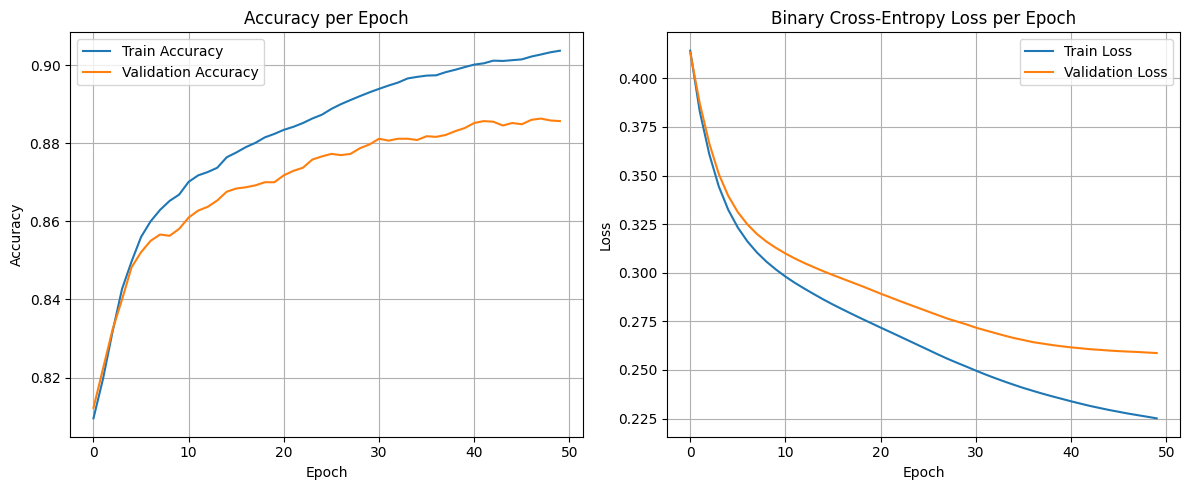

In [ ]:
# הגדרת המודל עם warm_start
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate='constant',
    learning_rate_init=0.001,
    max_iter=1,
    warm_start=True,
    random_state=1
)

# לולאת אימון
epochs = 50
train_loss, val_loss = [], []
train_acc, val_acc = [], []

for i in range(epochs):
    mlp.fit(X_tr_s, y_tr)
    train_prob = mlp.predict_proba(X_tr_s)
    val_prob = mlp.predict_proba(X_val_s)

    train_loss.append(log_loss(y_tr, train_prob))
    val_loss.append(log_loss(y_val, val_prob))

    train_acc.append(accuracy_score(y_tr, mlp.predict(X_tr_s)))
    val_acc.append(accuracy_score(y_val, mlp.predict(X_val_s)))

# ציור הגרפים
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title("Binary Cross-Entropy Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt


In [ ]:
print(f"Train Accuracy (last epoch): {train_acc[-1]}")
print(f"Validation Accuracy (last epoch): {val_acc[-1]}")

Train Accuracy (last epoch): 0.9036577005282898
Validation Accuracy (last epoch): 0.8856451612903226


# **Clustering**

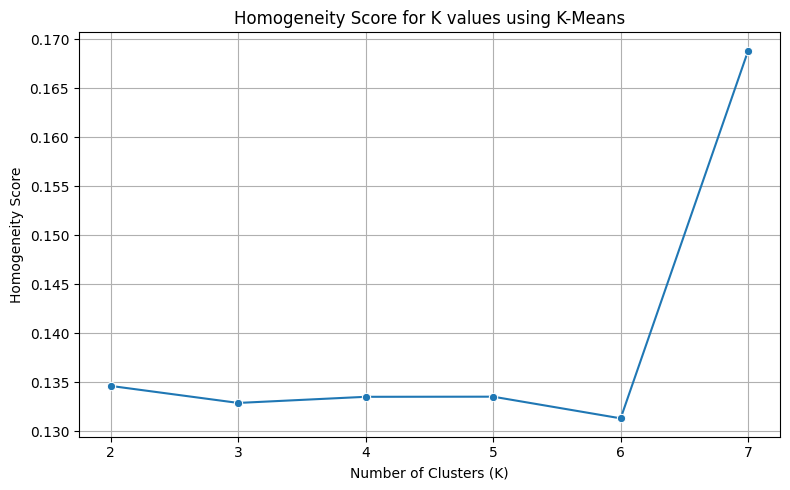

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import homogeneity_score
import matplotlib.pyplot as plt
import seaborn as sns


# בחירת פיצ'רים ותיוגים
features = ['engagement_rate', 'post_likes', 'Hashtags_Count']
df_clean = df[features + ['sentiment']].dropna()
X = df_clean[features]
y_true = df_clean['sentiment']

# נירמול
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# הרצת K-Means עבור ערכי K שונים ובדיקת הומוגניות
k_range = range(2, 8)
homogeneity_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    score = homogeneity_score(y_true, labels)
    homogeneity_scores.append(score)

# ציור הגרף
plt.figure(figsize=(8, 5))
sns.lineplot(x=list(k_range), y=homogeneity_scores, marker='o')
plt.title("Homogeneity Score for K values using K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Homogeneity Score")
plt.grid(True)
plt.tight_layout()
plt.show()


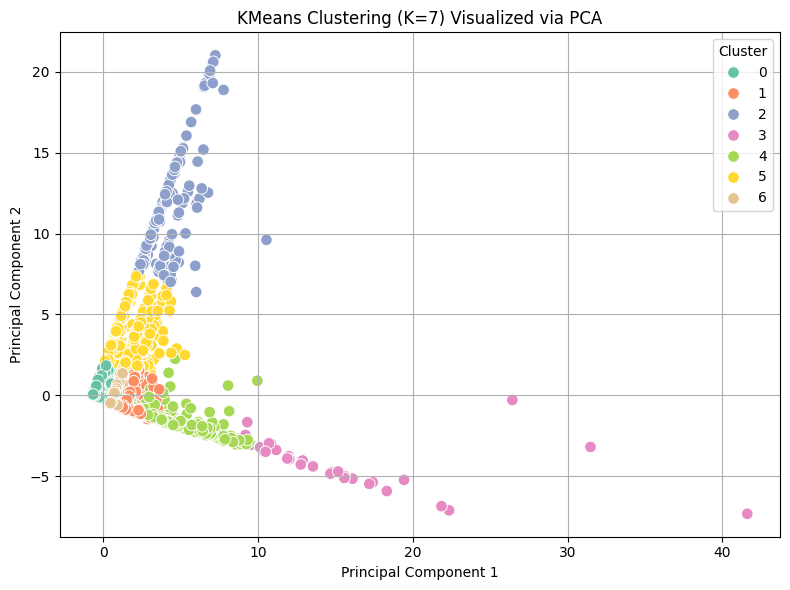

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

features = ['engagement_rate', 'post_likes', 'Hashtags_Count']
df_clean = df[features + ['sentiment']].dropna()

# נירמול
X = df_clean[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# הרצת KMeans עם K=7 (מהגרף שלך)
kmeans = KMeans(n_clusters=7, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# הפחתת מימדים ל־2D עם PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# הדמיה גרפית
df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_plot['Cluster'] = cluster_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=70)
plt.title("KMeans Clustering (K=7) Visualized via PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

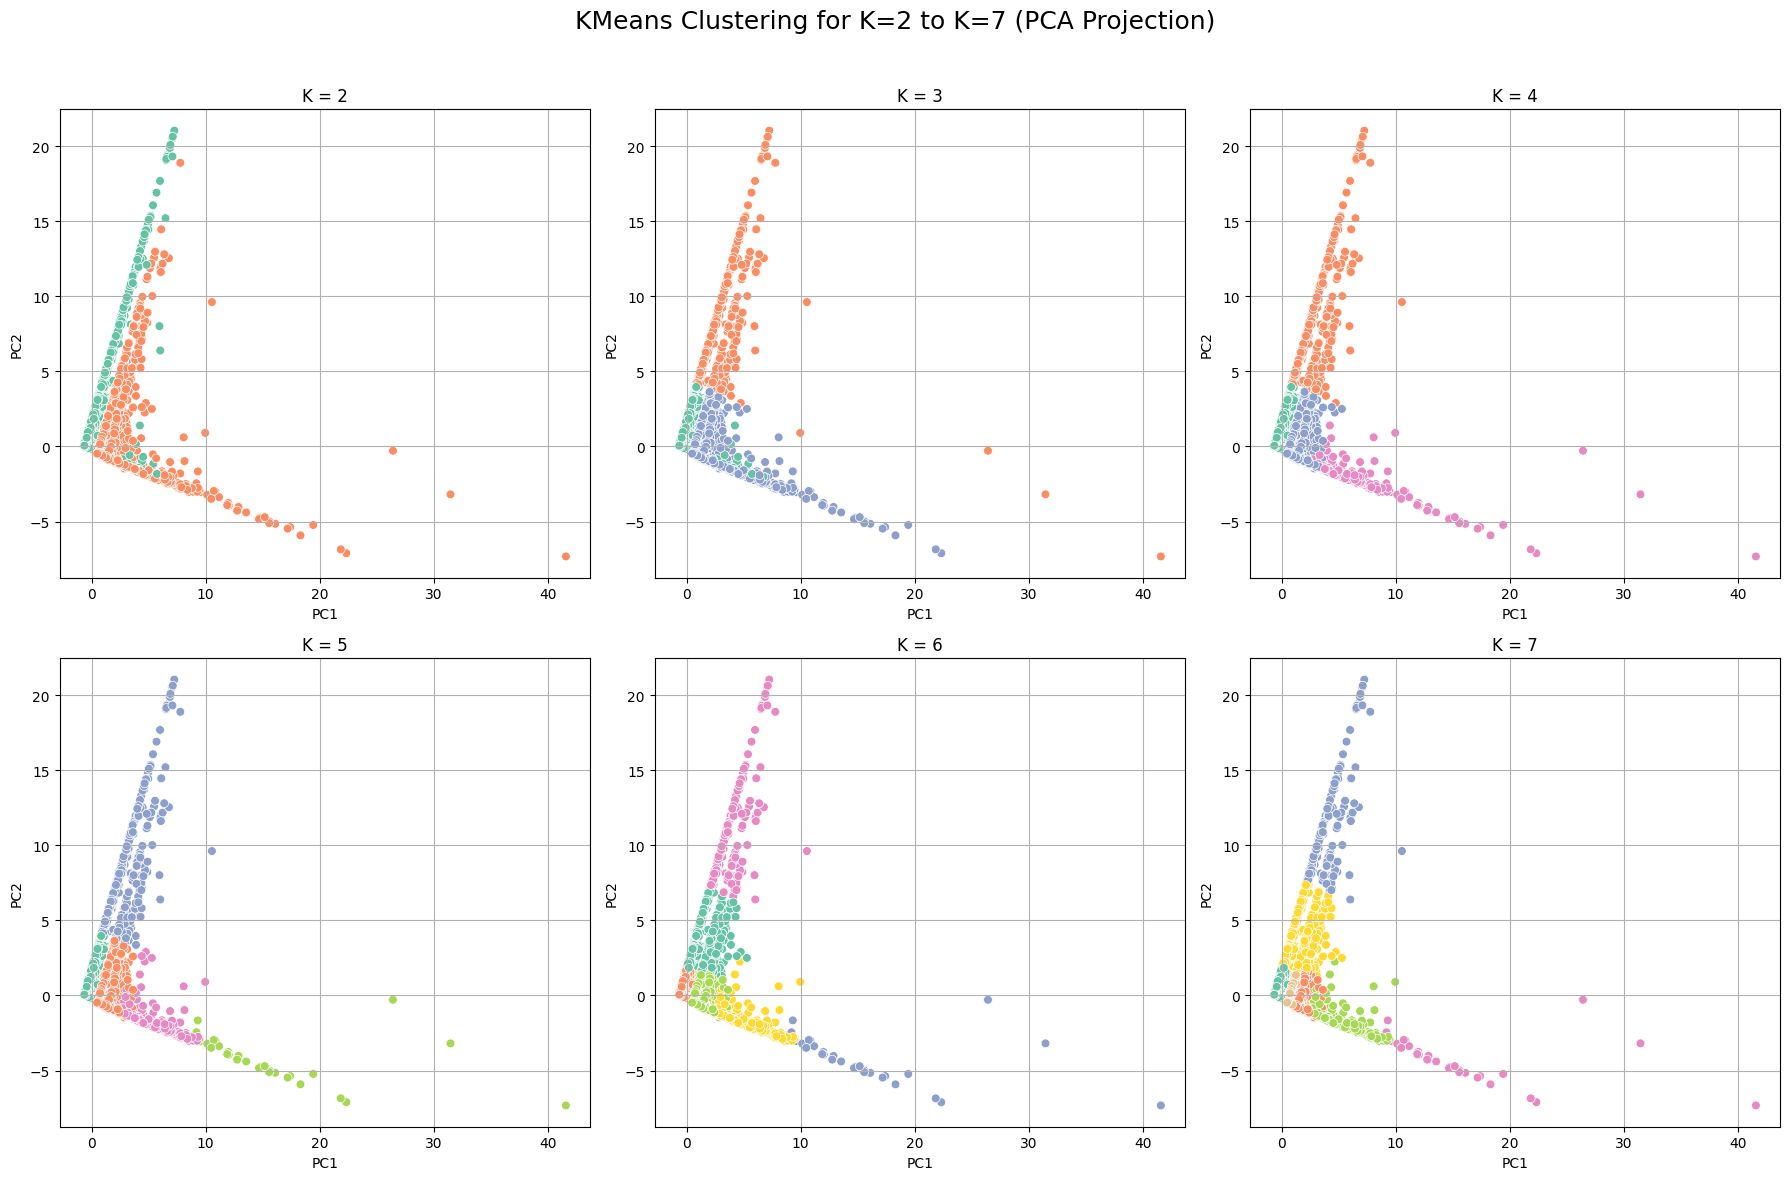

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# הגדרת פיצ'רים ושמירה רק על שורות ללא ערכים חסרים
features = ['engagement_rate', 'post_likes', 'Hashtags_Count']
df_clean = df[features + ['sentiment']].dropna()

# נירמול
X = df_clean[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# הפחתת מימדים ל-2D עם PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# יצירת גרפים עבור K = 2 עד 7
plt.figure(figsize=(18, 12))

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # הכנת DataFrame להדמיה
    df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_plot['Cluster'] = cluster_labels

    # יצירת subplot
    plt.subplot(2, 3, k - 1)
    sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=40, legend=False)
    plt.title(f"K = {k}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)

plt.suptitle("KMeans Clustering for K=2 to K=7 (PCA Projection)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# **ROC**

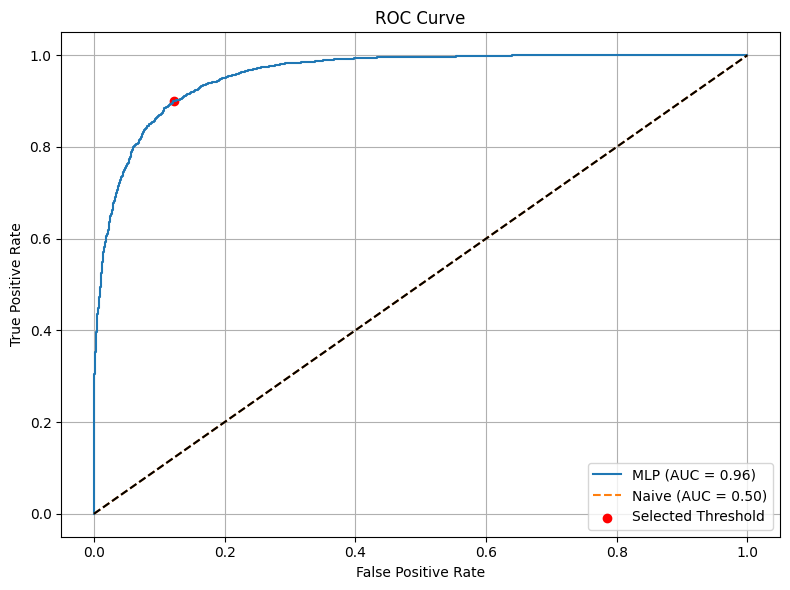

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt

# חיזוי הסתברויות על סט הוולידציה (רק מחלקה אחת אם בינארי)
y_val_proba = mlp.predict_proba(X_val_s)[:, 1]

# חישוב ROC
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

# מודל נאיבי
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_tr_s, y_tr)
y_dummy_proba = dummy.predict_proba(X_val_s)[:, 1]
fpr_dummy, tpr_dummy, _ = roc_curve(y_val, y_dummy_proba)
roc_auc_dummy = auc(fpr_dummy, tpr_dummy)

# ציור
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"MLP (AUC = {roc_auc:.2f})")
plt.plot(fpr_dummy, tpr_dummy, label=f"Naive (AUC = {roc_auc_dummy:.2f})", linestyle='--')
plt.scatter(fpr[np.argmax(tpr - fpr)], tpr[np.argmax(tpr - fpr)], c='red', label='Selected Threshold')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Thresholds: {thresholds}")
print(f"AUC: {roc_auc}")

Thresholds: [           inf 9.99989366e-01 9.84473197e-01 ... 1.29871333e-03
 1.29276541e-03 1.80850069e-07]
AUC: 0.9584734965145403


# **Confusion Matrix**

In [ ]:
# שלב 1: איחוד לצורך שמירה על סנכרון בין X ל-y
val_df = X_val.copy()
val_df['sentiment'] = y_val

# שלב 2: סינון רשומות עם ערכים חסרים
val_df_clean = val_df.dropna()

# שלב 3: הפרדה מחדש
X_val_clean = val_df_clean.drop('sentiment', axis=1)
y_val_clean = val_df_clean['sentiment']


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


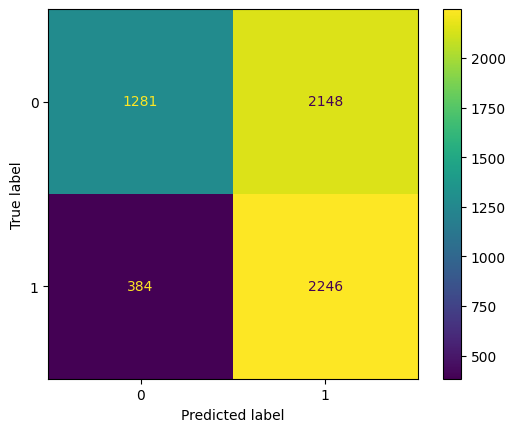

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ניצור מסכה שמסמנת את השורות שאין בהן NaN
mask = ~X_val.isna().any(axis=1)

# נסנן את שני המשתנים לפי אותה מסכה
X_val_clean = X_val[mask]
y_val_clean = y_val[mask.values]  # משתמשים ב-.values כדי להבטיח התאמה

# עכשיו אפשר להריץ
y_pred = model.predict(X_val_clean)
cm = confusion_matrix(y_val_clean, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
print(cm)

[[1281 2148]
 [ 384 2246]]


## **Improvments**

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# שלב 1: איזון סט האימון עם SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_imp, y_train_enc)

# שלב 2: נירמול (רק אחרי SMOTE)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_balanced)
X_test_s = scaler.transform(X_test_imp)

# שלב 3: אימון MLP
model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', max_iter=1000, random_state=42)
model.fit(X_train_s, y_train_balanced)

# שלב 4: ניבוי והערכת ביצועים על סט הוולידציה (המקורי, לא מאוזן)
y_pred = model.predict(X_test_s)

# שלב 5: הדפסת ביצועים
print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_enc, y_pred))
print("Classification Report:\n", classification_report(y_test_enc, y_pred))


Accuracy: 0.8929032258064517
Confusion Matrix:
 [[3948  440]
 [ 390 2972]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.90      4388
           1       0.87      0.88      0.88      3362

    accuracy                           0.89      7750
   macro avg       0.89      0.89      0.89      7750
weighted avg       0.89      0.89      0.89      7750



# **Test**

**Load Dataset of test**

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("test.csv")

# Convert numerical columns to numeric type (if not already)
numeric_columns = ['followers', 'previous_posts_count', 'post_likes', 'posts_retweets']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Calculate Engagement Rate
df = df[df['followers'] > 0]  # מניעת חילוק באפס
df.loc[:, 'engagement_rate'] = df['post_likes'] / df['followers']
df.to_csv('test.csv', index=False)

In [ ]:
from datetime import datetime

df['account_creation_date'] = pd.to_datetime(df['account_creation_date'], dayfirst=False)
# Calculate the number of months the user has been active
today = datetime.today()
df['months_active'] = ((today.year - df['account_creation_date'].dt.year) * 12) + (today.month - df['account_creation_date'].dt.month)
df.to_csv('sentiment.csv', index=False)

In [ ]:
df['birthday'] = pd.to_datetime(df['birthday'], dayfirst=True, errors='coerce')
df['age'] = (today - df['birthday']).dt.days // 365  # Calculate the user's age in years
df.to_csv('sentiment.csv', index=False)

<ipython-input-67-3105586973>:1: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['birthday'] = pd.to_datetime(df['birthday'], dayfirst=True, errors='coerce')


**Pre-Procecing**

In [ ]:
# Remove rows where 'followers' is '?'
df = df[df['followers'] != '?']
# Remove rows where 'username' is '?'
df = df[df['username'] != '?']

#Converting columns to binary
df['embedded_content_url'] = df['embedded_content_url'].apply(lambda x: 1 if pd.notnull(x) else 0)
df['profile_picture'] = df['profile_picture'].apply(lambda x: 1 if pd.notnull(x) else 0)
df['email'] = df['email'].apply(lambda x: 1 if pd.notnull(x) else 0).astype(int)
df['username'] = df['username'].apply(lambda x: 1 if pd.notnull(x) else 0).astype(int)
df.to_csv('sentiment.csv', index=False)

In [ ]:
df['post_datetime'] = pd.to_datetime(df['post_datetime'], errors='coerce', dayfirst=True)
# Retrieving the name of the day from the date
df['day_posted'] = df['post_datetime'].dt.day_name()
# One-Hot Encoding
df = pd.get_dummies(df, columns=['day_posted'], prefix='day_posted')
df.to_csv('sentiment.csv', index=False)

<ipython-input-69-2154135906>:1: UserWarning: Parsing dates in %m/%d/%Y %H:%M format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['post_datetime'] = pd.to_datetime(df['post_datetime'], errors='coerce', dayfirst=True)


In [ ]:
df['hour_posted'] = df['post_datetime'].dt.hour
# Division into categories by hours
df['time_of_day'] = pd.cut(
    df['hour_posted'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
    right=False
)

# One-Hot Encoding
df = pd.get_dummies(df, columns=['time_of_day'], prefix='time_of_day')
df.to_csv('sentiment.csv', index=False)

In [ ]:
# Make sure the dates are correct
df['post_datetime'] = pd.to_datetime(df['post_datetime'], dayfirst=True, errors='coerce')
df['Is_Weekend'] = df['post_datetime'].dt.weekday.isin([5, 6]).astype(int)
df.to_csv('sentiment.csv', index=False)

In [ ]:
df['Text_length'] = df['text'].apply(lambda x: len(x.split()) if pd.notnull(x) else 0)
df.to_csv('sentiment.csv', index=False)

In [ ]:
words_df = pd.read_excel('sentiment_words.xlsx')
positive_words = words_df['positive_words'].dropna().tolist()
negative_words = words_df['negative_words'].dropna().tolist()

df['Positive_word_count'] = df['text'].apply(
    lambda x: sum(1 for word in str(x).lower().split() if word in positive_words)
)

df['Negative_word_count'] = df['text'].apply(
    lambda x: sum(1 for word in str(x).lower().split() if word in negative_words)
)
df.to_csv('sentiment.csv', index=False)

In [ ]:
# Calculate the ratio between positive and negative words
df['Sentiment_Ratio'] = df['Positive_word_count'] / (df['Negative_word_count'] + 1)  # Adding 1 to prevent division by 0

# Calculate the number of hashtags in a message
df['Hashtags_Count'] = df['text'].apply(lambda x: x.count('#'))
df.to_csv('sentiment.csv', index=False)

In [ ]:
pip install emoji

In [ ]:
import emoji

# Function that counts emojis in text
def count_emojis(text):
    return sum(1 for char in text if char in emoji.EMOJI_DATA)

# Adding a new column to the DataFrame
df['emoji_count'] = df['text'].astype(str).apply(count_emojis)
df.to_csv('sentiment.csv', index=False)

In [ ]:
df = df.drop(columns=['followers', 'posts_retweets', 'emoji_count'])
df.to_csv('sentiment.csv', index=False)

In [ ]:
type_mapping = {'post': 1, 'reply': 2, 'retweet': 3}
df['type'] = df['type'].map(type_mapping)
df.to_csv('sentiment.csv', index=False)

In [ ]:
checkmark_map = {
    'none': 0,   # Private, free account
    'blue': 1,   # Private, Premium Account
    'gold': 2,   # Official account of an organization
    'grey': 3    # חשבון רשמי של ממשלה
}

# המרה ל-label encoding
df['checkmark'] = df['checkmark'].map(checkmark_map)
df.to_csv('sentiment.csv', index=False)

In [ ]:
# Mapping of acronyms to hours from UTC
timezone_offset_map = {
    'GMT': 0,
    'UTC': 0,
    'EST': -5,
    'CST': -6,
    'MST': -7,
    'PST': -8,
    'EET': 2,
    'CET': 1,
    'MSK': 3,
    'AEST': 10,
    'ACST': 9.5,
    'AWST': 8
}

df['timezone_offset'] = df['timezone'].map(timezone_offset_map).fillna(0)
df.to_csv('sentiment.csv', index=False)

In [ ]:
# רשימת העמודות לעיבוד
columns_to_convert = [
    'day_posted_Sunday',
    'day_posted_Saturday',
    'day_posted_Friday',
    'day_posted_Monday',
    'day_posted_Tuesday',
    'day_posted_Wednesday',
    'day_posted_Thursday',
    'time_of_day_Night',
    'time_of_day_Morning',
    'time_of_day_Afternoon',
    'time_of_day_Evening'
]

# המרת ערכים בוליאניים ל-0/1
for col in columns_to_convert:
    df[col] = df[col].astype(int)
df.to_csv('sentiment.csv', index=False)

**Predict**

In [ ]:
# שלב 1: שכפול הנתונים
df_clean = df.copy()

# שלב 2: הסרת עמודות לא רלוונטיות
X = df_clean.drop(['id', 'text', 'post_datetime', 'timezone', 'account_creation_date', 'birthday'], axis=1)

# שלב 3: עיבוד כמו ב-train
X_imputed = imputer.transform(X)
X_scaled = scaler.transform(X_imputed)

# תחזית (לא הסתברויות!)
y_pred_test = model.predict(X_scaled)
print("Shape of prediction:", y_pred_test.shape)  # <<< לוודא שזה (n,)

# הוספת התחזית לדאטה
df_clean['predicted_sentiment'] = y_pred_test

# המרה חזרה לקטגוריות (אם רוצים)
reverse_map = {0: 'negative', 1: 'positive'}
df_clean['predicted_sentiment'] = df_clean['predicted_sentiment'].map(reverse_map)




Shape of prediction: (9926,)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
from google.colab import files

# שלב 1: יצירת DataFrame עם העמודות הרצויות
output_df = df_clean[['id', 'predicted_sentiment']].copy()
output_df.rename(columns={'predicted_sentiment': 'sentiment'}, inplace=True)

# שלב 2: שמירה לקובץ CSV
filename = 'group3.csv'
output_df.to_csv(filename, index=False, encoding='utf-8')

# שלב 3: הורדה למחשב האישי
files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>